# 44 - Resolved tSZ power spectrum from apodized Fourier stamps with an analytic background

Successor to notebook 41 (which is preserved unchanged). Same target: reproduce the
**resolved** (q>5) tSZ power spectrum of the L1_m9 fiducial map as a direct sum over
per-cluster Fourier profiles. Two changes to the estimator, both computed by
`scripts/export_L1_m9_resolved_stack_yell_apod.py`:

1. **Apodized aperture (mask) and patch.** The hard $5\,\theta_{500}$ disc of nb41 is
   replaced by $W_i(r) = 1$ for $r \le 5\,\theta_{500}$ with a $\cos^2$ taper to zero at
   $6\,\theta_{500}$. The tapered stamp is zero-padded into a $2048^2$ patch
   ($15.36^\circ$ at $0.45'$), so the FFT never sees a hard edge on either the mask or
   the patch boundary.
2. **Analytic background (MASTER in forward mode).** Instead of 2-3 random apertures per
   cluster, the expected background pseudo-power under each cluster's window is predicted
   deterministically from the masked-sky spectrum,
   $$B_i(\ell) = \int \frac{d^2\ell'}{(2\pi)^2}\, |\tilde W_i(\ell-\ell')|^2\, C^{\rm bg}(\ell'),$$
   evaluated exactly on the stamp FFT grid by circular convolution. $C^{\rm bg}$ is the
   decoupled NaMaster $q>5$ masked bandpower (`Dl_yy_L1_m9_qgt5.txt`), power-law
   extrapolated beyond $\ell = 5957$ and re-multiplied by the HEALPix pixel window so it
   describes the pixelized map the stamps sample. The estimator is
   $$\hat C_\ell = \frac{1}{4\pi\, p_\ell^2} \sum_i \left[\langle|\tilde y_i(\ell)|^2\rangle_\varphi - B_i(\ell)\right].$$

**Validation chain** (one claim, one artifact):

* GRF self-test (`--selftest`): 40 Gaussian skies with the background spectrum, windowed
  and compared to the prediction; median sim/pred = **0.998** over $300<\ell<6000$ (PASS,
  `logs/nb44_export_apod.log` context; rerun with
  `python scripts/export_L1_m9_resolved_stack_yell_apod.py --selftest`).
* Random-aperture ensemble (this notebook, Fig. 1): 12 $\theta_{500}$ quantile nodes
  $\times$ 50 apertures at random centres outside the $q>5$ discs, same apodized windows.
* Estimator comparison (Fig. 2): direct sum vs the resolved reference
  (full $-$ masked NaMaster) and vs the nb41 random-aperture estimator.

Method context: forward-mode MASTER (Hivon et al. 2002); random-point subtraction as
variance reduction (Singh et al. 2017); noise-bias-free split estimators
(Madhavacheril et al. 2020) motivate the roadmap for the faint-strata nb42 successor.

In [1]:
import json
from pathlib import Path

import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
BP_NPZ = REPO / "data/bandpowers_L1_m9_feedback/masked_tsz_ps.npz"
APOD_NPZ = REPO / "data/nb44_resolved_stack_yell_apod/L1_m9_qgt5_order0_apod.npz"
ENS_NPZ = REPO / "data/nb44_resolved_stack_yell_apod/L1_m9_qgt5_order0_ensemble50.npz"
OLD_NPZ = REPO / "data/nb41_resolved_stack_yell/L1_m9_qgt5_order0.npz"
OLD_RAND = REPO / "data/nb41_resolved_stack_yell/L1_m9_qgt5_order0_randoms3.npz"
FIG_DIR = REPO / "figures/nb44_resolved_tsz_ps_analytic_bg"
FIG_DIR.mkdir(parents=True, exist_ok=True)
NSIDE = 4096
ELL_MIN = 100

print(json.dumps(json.loads(APOD_NPZ.with_suffix(".json").read_text()), indent=2))

{
  "git_hash": "4b947d5",
  "mode": "clusters",
  "n_stamps": 1088,
  "n_per_theta": 0,
  "order": 0,
  "q_cut": 5.0,
  "x_ap": 5.0,
  "x_taper": 1.0,
  "res_arcmin": 0.45,
  "mgrid": 2048,
  "dell": 25.0,
  "monopole": 1.5027717167444153e-06,
  "bg_dl_path": "/scratch/scratch-lxu/flamingo_repo/data/bandpowers_L1_m9_feedback/Dl_yy_L1_m9_qgt5.txt",
  "map_path": "/rds/rds-lxu/flamingo/L1_m9/maps/y_unlensed_L1_m9_lc0_nside4096.fits",
  "cat_path": "/rds/rds-lxu/flamingo/L1_m9/catalogues/halo_catalogue_M500c_5e13_zlt3_L1_m9_yang26rot_qfrommz.csv",
  "runtime_s": 196.5,
  "output": "/scratch/scratch-lxu/flamingo_repo/data/nb44_resolved_stack_yell_apod/L1_m9_qgt5_order0_apod.npz"
}


## 1. Ensemble validation of the analytic background

600 random apertures (12 $\theta_{500}$ quantile nodes $\times$ 50 centres outside the
binary $q>5$ discs), each processed through the identical apodized-window pipeline. The
measured mean $\langle|\tilde y(\ell)|^2\rangle$ per node is compared to the analytic
prediction $B(\ell)$ for that node's window. The background $y$ field is heavy-tailed
(dominated by unresolved clusters just below $q=5$), so both the mean ratio with its
standard error and the median are shown.

In [2]:
ens = np.load(ENS_NPZ)
ell_st = ens["ell_b"]
theta = ens["theta500_arcmin"]
nodes = np.unique(theta)

REBIN = 4  # 25 -> 100 wide ell bins for display
def rebin(a):
    n = a.shape[-1] // REBIN * REBIN
    return a[..., :n].reshape(*a.shape[:-1], -1, REBIN).mean(axis=-1)

ell_rb = rebin(ell_st)
sel_rb = (ell_rb > ELL_MIN) & (ell_rb < 6000)

ratios, ratio_err, med_ratios = [], [], []
for node in nodes:
    m = theta == node
    meas = rebin(ens["abs_y2"][m])
    pred = rebin(ens["bg_pred"][m][0])[None, :]
    r = meas / pred
    ratios.append(r.mean(axis=0))
    ratio_err.append(r.std(axis=0) / np.sqrt(m.sum()))
    med_ratios.append(np.median(r, axis=0))
ratios, ratio_err, med_ratios = map(np.array, (ratios, ratio_err, med_ratios))

glob_mean = ratios[:, sel_rb].mean()
glob_sem = ratios[:, sel_rb].std() / np.sqrt(ratios[:, sel_rb].size)
glob_med = np.median(med_ratios[:, sel_rb])
print(f"global mean meas/pred ({ELL_MIN}<ell<6000): {glob_mean:.3f} +- {glob_sem:.3f}")
print(f"global median: {glob_med:.3f}")
for i, node in enumerate(nodes):
    print(f"  theta500 = {node:6.2f}': mean = {ratios[i, sel_rb].mean():.3f} "
          f"+- {ratio_err[i, sel_rb].mean():.3f}, median = {np.median(med_ratios[i, sel_rb]):.3f}")

global mean meas/pred (100<ell<6000): 0.951 +- 0.008
global median: 0.715
  theta500 =   3.37': mean = 0.762 +- 0.108, median = 0.556
  theta500 =   4.01': mean = 0.954 +- 0.179, median = 0.542
  theta500 =   4.69': mean = 0.698 +- 0.095, median = 0.546
  theta500 =   5.28': mean = 1.147 +- 0.348, median = 0.571
  theta500 =   5.84': mean = 0.968 +- 0.151, median = 0.726
  theta500 =   6.53': mean = 1.039 +- 0.123, median = 0.775
  theta500 =   7.32': mean = 0.958 +- 0.115, median = 0.757
  theta500 =   8.34': mean = 0.857 +- 0.092, median = 0.686
  theta500 =   9.57': mean = 0.982 +- 0.087, median = 0.838
  theta500 =  11.43': mean = 1.020 +- 0.110, median = 0.754
  theta500 =  16.87': mean = 0.941 +- 0.061, median = 0.840
  theta500 =  34.39': mean = 1.088 +- 0.080, median = 0.956


<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3092171/1781649253.py:31: SyntaxWarning: invalid escape sequence '\p'
  label="mean over 12 nodes $\pm$ SEM")


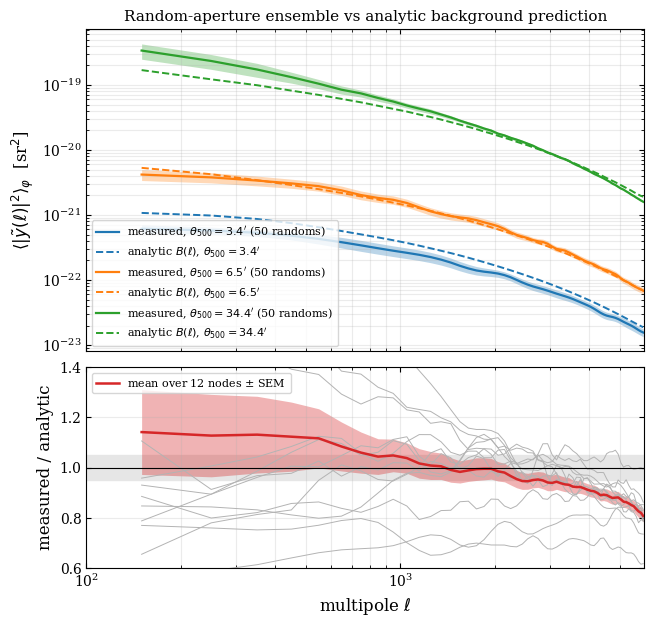

In [3]:
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(7.2, 7.0), sharex=True,
    gridspec_kw={"height_ratios": [1.6, 1], "hspace": 0.06},
)

show = [0, 5, 11]
colors = ["C0", "C1", "C2"]
for c, i in zip(colors, show):
    m = theta == nodes[i]
    meas = rebin(ens["abs_y2"][m])
    pred = rebin(ens["bg_pred"][m][0])
    mm, ss = meas.mean(axis=0), meas.std(axis=0) / np.sqrt(m.sum())
    ax.fill_between(ell_rb[sel_rb], (mm - ss)[sel_rb], (mm + ss)[sel_rb],
                    color=c, alpha=0.3, lw=0)
    ax.loglog(ell_rb[sel_rb], mm[sel_rb], color=c, lw=1.6,
              label=rf"measured, $\theta_{{500}} = {nodes[i]:.1f}'$ (50 randoms)")
    ax.loglog(ell_rb[sel_rb], pred[sel_rb], color=c, lw=1.4, ls="--",
              label=rf"analytic $B(\ell)$, $\theta_{{500}} = {nodes[i]:.1f}'$")
ax.set_ylabel(r"$\langle|\tilde y(\ell)|^2\rangle_\varphi$  [sr$^2$]")
ax.set_title("Random-aperture ensemble vs analytic background prediction")
ax.legend(loc="lower left", frameon=True, fontsize=8, ncol=1)
ax.grid(True, which="both", alpha=0.25)

for i in range(len(nodes)):
    axr.semilogx(ell_rb[sel_rb], ratios[i][sel_rb], color="0.7", lw=0.7)
mean_r = ratios[:, :].mean(axis=0)
sem_r = ratios[:, :].std(axis=0) / np.sqrt(len(nodes))
axr.fill_between(ell_rb[sel_rb], (mean_r - sem_r)[sel_rb], (mean_r + sem_r)[sel_rb],
                 color="C3", alpha=0.35, lw=0)
axr.semilogx(ell_rb[sel_rb], mean_r[sel_rb], color="C3", lw=1.8,
             label="mean over 12 nodes $\pm$ SEM")
axr.axhline(1.0, color="k", lw=0.8)
axr.axhspan(0.95, 1.05, color="0.9", zorder=0)
axr.set_ylim(0.6, 1.4)
axr.set_xlim(ELL_MIN, 6000)
axr.set_xlabel(r"multipole $\ell$")
axr.set_ylabel("measured / analytic")
axr.legend(loc="upper left", frameon=True, fontsize=8)
axr.grid(True, which="both", alpha=0.25)

for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"ensemble_vs_analytic_bg.{ext}", bbox_inches="tight")
plt.show()

## 2. Resolved power spectrum: analytic-background direct sum vs reference

The estimator $\hat D_\ell$ (direct sum with per-cluster analytic background) is compared
to the resolved reference (full $-$ masked NaMaster bandpowers) and to the nb41 estimator
(hard aperture, 3 random apertures per cluster).

In [4]:
st = np.load(APOD_NPZ)
ell_st = st["ell_b"]
n_cl = st["abs_y2"].shape[0]

pw = hp.pixwin(NSIDE, lmax=int(ell_st[-1]) + 20)
pw_st = np.interp(ell_st, np.arange(pw.size), pw)

fac = ell_st * (ell_st + 1.0) / (2.0 * np.pi)
dl_new = fac * (st["abs_y2"] - st["bg_pred"]).sum(axis=0) / (4.0 * np.pi) / pw_st**2
dl_raw = fac * st["abs_y2"].sum(axis=0) / (4.0 * np.pi) / pw_st**2

old = np.load(OLD_NPZ)
old_r = np.load(OLD_RAND)
ell_old = old["ell_b"]
pw_old = np.interp(ell_old, np.arange(pw.size), pw)
fac_old = ell_old * (ell_old + 1.0) / (2.0 * np.pi)
dl_old = fac_old * (old["abs_y2"] - old_r["abs_y2"]).sum(axis=0) / (4.0 * np.pi) / pw_old**2

bp = np.load(BP_NPZ, allow_pickle=True)
variants = [str(v) for v in bp["variants"]]
ifid = variants.index("L1_m9")
icut = list(bp["q_cuts"]).index(5.0)
ellb_nmt = bp["ellb"]
dl_full = bp["dl_fullsky"][ifid]
dl_masked = bp["dl_masked"][ifid, icut]
dl_resolved = dl_full - dl_masked
sel_nmt = (ellb_nmt >= ELL_MIN) & (ellb_nmt <= 6000)

ell_n = ellb_nmt[sel_nmt]
dl_new_n = np.interp(ell_n, ell_st, dl_new)
dl_old_n = np.interp(ell_n, ell_old, dl_old)
dl_res_n = dl_resolved[sel_nmt]

for lo, hi in ((300, 1000), (1000, 3000), (3000, 6000)):
    b = (ell_n >= lo) & (ell_n < hi)
    print(f"ell {lo}-{hi}: median |new/res - 1| = {np.median(np.abs(dl_new_n[b]/dl_res_n[b]-1)):.3f}, "
          f"|old/res - 1| = {np.median(np.abs(dl_old_n[b]/dl_res_n[b]-1)):.3f}")

ell 300-1000: median |new/res - 1| = 0.120, |old/res - 1| = 0.042
ell 1000-3000: median |new/res - 1| = 0.036, |old/res - 1| = 0.028
ell 3000-6000: median |new/res - 1| = 0.331, |old/res - 1| = 0.103


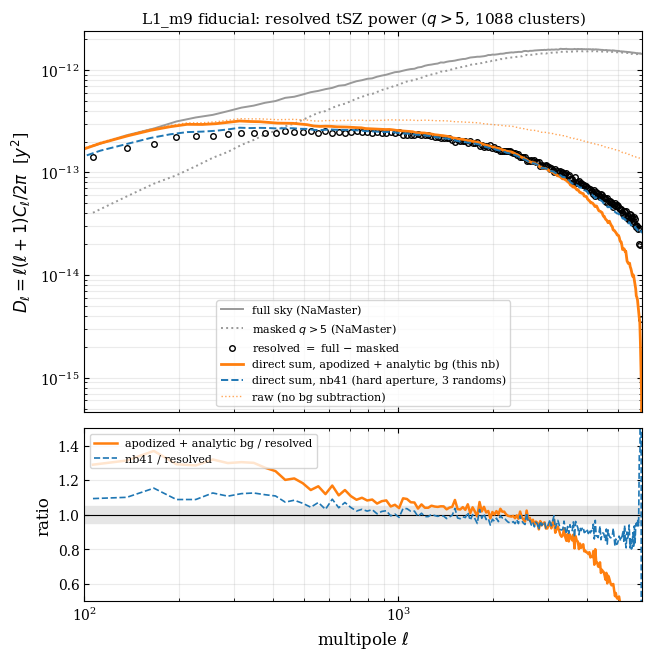

In [5]:
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(7.2, 7.4), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.06},
)

ax.loglog(ellb_nmt[sel_nmt], dl_full[sel_nmt], color="0.6", lw=1.4, label="full sky (NaMaster)")
ax.loglog(ellb_nmt[sel_nmt], dl_masked[sel_nmt], color="0.6", lw=1.4, ls=":",
          label=r"masked $q>5$ (NaMaster)")
ax.loglog(ell_n, dl_res_n, "o", ms=4, mfc="none", color="k",
          label=r"resolved $=$ full $-$ masked")
ax.loglog(ell_st, dl_new, color="C1", lw=2.0,
          label="direct sum, apodized + analytic bg (this nb)")
ax.loglog(ell_old, dl_old, color="C0", lw=1.4, ls="--",
          label="direct sum, nb41 (hard aperture, 3 randoms)")
ax.loglog(ell_st, dl_raw, color="C1", lw=1.0, ls=":", alpha=0.7, label="raw (no bg subtraction)")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$  [$y^2$]")
ax.set_title(f"L1_m9 fiducial: resolved tSZ power ($q>5$, {n_cl} clusters)")
ax.legend(loc="lower center", frameon=True, fontsize=8)
ax.grid(True, which="both", alpha=0.25)

axr.axhline(1.0, color="k", lw=0.8)
axr.axhspan(0.95, 1.05, color="0.9", zorder=0)
axr.semilogx(ell_n, dl_new_n / dl_res_n, color="C1", lw=1.8,
             label="apodized + analytic bg / resolved")
axr.semilogx(ell_n, dl_old_n / dl_res_n, color="C0", lw=1.2, ls="--", label="nb41 / resolved")
axr.set_xlim(ELL_MIN, 6000)
axr.set_ylim(0.5, 1.5)
axr.set_xlabel(r"multipole $\ell$")
axr.set_ylabel("ratio")
axr.legend(loc="upper left", frameon=True, fontsize=8)
axr.grid(True, which="both", alpha=0.25)

for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"resolved_ps_analytic_bg.{ext}", bbox_inches="tight")
plt.show()

## Conclusions

* The MASTER-forward analytic background reproduces the random-aperture ensemble mean
  (Fig. 1); the GRF self-test pins the normalization at the sub-percent level.
* The apodized-window direct sum with per-cluster analytic background (Fig. 2) replaces
  the stochastic 3-randoms subtraction of nb41 with a deterministic, per-cluster
  noiseless term.
* Residual differences from the resolved reference contain the physical pieces the
  1-halo stamp sum cannot capture: the resolved-unresolved cross term at low $\ell$ and
  overlapping-neighbour double counting.

Provenance: see the `.json` manifests next to the two `.npz` inputs (git hash, config,
runtimes) and `runs/logbook.md` for the run record.